In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 깨짐 방지(윈도우 기본 폰트)
plt.rcParams["axes.unicode_minus"] = False

2. 데이터 정보확인
- 행, 열 개수
- 결측치
- 타입체크

In [ ]:
df = pd.read_csv("../data/07-9_bike_ttareungi.csv")
df.head()
# 

,대여일자,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분)
0,202606,1201,1201. 가락시장역 3번 출구,정기권,NaN,30대,123,8750.55,78.97,339960.75,2621
1,202606,5339,5339. 은빛1단지 아파트 앞,정기권,M,~10대,15,517.56,4.65,20107.79,173
2,202606,3928,3928.고척아이파크아파트 106동 앞,일일권,NaN,40대,7,444.12,4.00,17254.05,148
3,202606,102,102. 망원역 1번출구 앞,가족권(2시간),M,~10대,1,181.72,1.64,7060.00,66
4,202606,2265,2265. 이수고가차도 남단,일일권,F,50대,6,660.63,5.96,25665.78,220


In [7]:
df.shape

(5000, 11)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   대여일자     5000 non-null   int64  
 1   대여소번호    5000 non-null   int64  
 2   대여소명     5000 non-null   str    
 3   대여구분코드   5000 non-null   str    
 4   성별       3188 non-null   str    
 5   연령대코드    5000 non-null   str    
 6   이용건수     5000 non-null   int64  
 7   운동량      4992 non-null   float64
 8   탄소량      4992 non-null   float64
 9   이동거리(M)  5000 non-null   float64
 10  이용시간(분)  5000 non-null   int64  
dtypes: float64(3), int64(4), str(4)
memory usage: 666.6 KB


In [6]:
df.isna().sum()

대여일자          0
대여소번호         0
대여소명          0
대여구분코드        0
성별         1812
연령대코드         0
이용건수          0
운동량           8
탄소량           8
이동거리(M)       0
이용시간(분)       0
dtype: int64

In [44]:
# 월 컬럼 생성
df['월']=df['대여일자'].astype(str).apply(lambda x: x[-2:])# 뒤에 추가 람다 사용 뒤에 무조건 추가 

df.head()

,대여일자,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분),월,운동량/건별,탄소량/건별,이동거리(M)/건별,이용시간(분)/건별
0,2026-06-01,1201,1201. 가락시장역 3번 출구,정기권,NaN,30대,123,8750.55,78.97,339960.75,2621,01,71.14,0.64,2763.91,21.31
1,2026-06-01,5339,5339. 은빛1단지 아파트 앞,정기권,M,~10대,15,517.56,4.65,20107.79,173,01,34.50,0.31,1340.52,11.53
2,2026-06-01,3928,3928.고척아이파크아파트 106동 앞,일일권,NaN,40대,7,444.12,4.00,17254.05,148,01,63.45,0.57,2464.86,21.14
3,2026-06-01,102,102. 망원역 1번출구 앞,가족권(2시간),M,~10대,1,181.72,1.64,7060.00,66,01,181.72,1.64,7060.00,66.00
4,2026-06-01,2265,2265. 이수고가차도 남단,일일권,F,50대,6,660.63,5.96,25665.78,220,01,110.10,0.99,4277.63,36.67


In [11]:
df['월'].unique

<bound method Series.unique of 0       06
1       06
2       06
3       06
4       06
        ..
4995    06
4996    06
4997    06
4998    06
4999    06
Name: 월, Length: 5000, dtype: str>

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   대여일자     5000 non-null   datetime64[us]
 1   대여소번호    5000 non-null   int64         
 2   대여소명     5000 non-null   str           
 3   대여구분코드   5000 non-null   str           
 4   성별       3188 non-null   str           
 5   연령대코드    5000 non-null   str           
 6   이용건수     5000 non-null   int64         
 7   운동량      4992 non-null   float64       
 8   탄소량      4992 non-null   float64       
 9   이동거리(M)  5000 non-null   float64       
 10  이용시간(분)  5000 non-null   int64         
 11  월        5000 non-null   str           
dtypes: datetime64[us](1), float64(3), int64(3), str(5)
memory usage: 715.4 KB


In [51]:
df['대여일자'] = pd.to_datetime(df['대여일자'], format='%Y%m')
df.head()

,대여일자,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분),월,운동량/건별,탄소량/건별,이동거리(M)/건별,이용시간(분)/건별
0,2026-06-01,1201,1201. 가락시장역 3번 출구,정기권,NaN,30대,123,8750.55,78.97,339960.75,2621,6,71.14,0.64,2763.91,21.31
1,2026-06-01,5339,5339. 은빛1단지 아파트 앞,정기권,M,~10대,15,517.56,4.65,20107.79,173,6,34.50,0.31,1340.52,11.53
2,2026-06-01,3928,3928.고척아이파크아파트 106동 앞,일일권,NaN,40대,7,444.12,4.00,17254.05,148,6,63.45,0.57,2464.86,21.14
3,2026-06-01,102,102. 망원역 1번출구 앞,가족권(2시간),M,~10대,1,181.72,1.64,7060.00,66,6,181.72,1.64,7060.00,66.00
4,2026-06-01,2265,2265. 이수고가차도 남단,일일권,F,50대,6,660.63,5.96,25665.78,220,6,110.10,0.99,4277.63,36.67


In [50]:
df.drop('월', axis=1)
df.head()

,대여일자,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분),월,운동량/건별,탄소량/건별,이동거리(M)/건별,이용시간(분)/건별
0,2026-06-01,1201,1201. 가락시장역 3번 출구,정기권,NaN,30대,123,8750.55,78.97,339960.75,2621,6,71.14,0.64,2763.91,21.31
1,2026-06-01,5339,5339. 은빛1단지 아파트 앞,정기권,M,~10대,15,517.56,4.65,20107.79,173,6,34.50,0.31,1340.52,11.53
2,2026-06-01,3928,3928.고척아이파크아파트 106동 앞,일일권,NaN,40대,7,444.12,4.00,17254.05,148,6,63.45,0.57,2464.86,21.14
3,2026-06-01,102,102. 망원역 1번출구 앞,가족권(2시간),M,~10대,1,181.72,1.64,7060.00,66,6,181.72,1.64,7060.00,66.00
4,2026-06-01,2265,2265. 이수고가차도 남단,일일권,F,50대,6,660.63,5.96,25665.78,220,6,110.10,0.99,4277.63,36.67


In [49]:
df['월'] = df['대여일자'].dt.month
df.head()

,대여일자,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분),월,운동량/건별,탄소량/건별,이동거리(M)/건별,이용시간(분)/건별
0,2026-06-01,1201,1201. 가락시장역 3번 출구,정기권,NaN,30대,123,8750.55,78.97,339960.75,2621,6,71.14,0.64,2763.91,21.31
1,2026-06-01,5339,5339. 은빛1단지 아파트 앞,정기권,M,~10대,15,517.56,4.65,20107.79,173,6,34.50,0.31,1340.52,11.53
2,2026-06-01,3928,3928.고척아이파크아파트 106동 앞,일일권,NaN,40대,7,444.12,4.00,17254.05,148,6,63.45,0.57,2464.86,21.14
3,2026-06-01,102,102. 망원역 1번출구 앞,가족권(2시간),M,~10대,1,181.72,1.64,7060.00,66,6,181.72,1.64,7060.00,66.00
4,2026-06-01,2265,2265. 이수고가차도 남단,일일권,F,50대,6,660.63,5.96,25665.78,220,6,110.10,0.99,4277.63,36.67


In [48]:
df['성별'].unique()

<ArrowStringArray>
[nan, 'M', 'F']
Length: 3, dtype: str

In [47]:
df['운동량/건별'] = (df['운동량'] / df['이용건수']).round(2) #round를 사용해서 소수점 2번째까지 출력 가능 
df['탄소량/건별'] = (df['탄소량'] / df['이용건수']).round(2)
df['이동거리(M)/건별'] = (df['이동거리(M)']/ df['이용건수']).round(2)
df['이용시간(분)/건별']= (df['이용시간(분)']/ df['이용건수']).round(2)
df.head()

,대여일자,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분),월,운동량/건별,탄소량/건별,이동거리(M)/건별,이용시간(분)/건별
0,2026-06-01,1201,1201. 가락시장역 3번 출구,정기권,NaN,30대,123,8750.55,78.97,339960.75,2621,01,71.14,0.64,2763.91,21.31
1,2026-06-01,5339,5339. 은빛1단지 아파트 앞,정기권,M,~10대,15,517.56,4.65,20107.79,173,01,34.50,0.31,1340.52,11.53
2,2026-06-01,3928,3928.고척아이파크아파트 106동 앞,일일권,NaN,40대,7,444.12,4.00,17254.05,148,01,63.45,0.57,2464.86,21.14
3,2026-06-01,102,102. 망원역 1번출구 앞,가족권(2시간),M,~10대,1,181.72,1.64,7060.00,66,01,181.72,1.64,7060.00,66.00
4,2026-06-01,2265,2265. 이수고가차도 남단,일일권,F,50대,6,660.63,5.96,25665.78,220,01,110.10,0.99,4277.63,36.67


In [46]:
df['대여일자'].head()

0   2026-06-01
1   2026-06-01
2   2026-06-01
3   2026-06-01
4   2026-06-01
Name: 대여일자, dtype: datetime64[us]

In [52]:
(df['연령대코드'] == '기타').sum()

np.int64(427)

In [ ]:
#데이터 탐색
#궁금한 것 위주
# 1. 성별로 이용시간은 어떻게 될까
# 2. 성별로 이동시간은 어떻게 될까
# 3. 가장많이 사용하는 대여소는 어떻게 될까
# 4. 대여소별 이용시간
# 5. 대여소별 이동시간

In [74]:
# df['성별'].unique()
df["성별"] = df["성별"].fillna("미상")
gender_time = df.groupby('성별')[['이동거리(M)/건별', '이용시간(분)/건별']].mean().reset_index() #group 사용
gender_time
# gender_data = (
#     df.groupby("성별", as_index=False)
#         ["이동거리(M)/건별","이용시간(분)/건별"].mean()
# )


gender_data = (
    df.groupby("성별", as_index=False)[
        ["이동거리(M)/건별", "이용시간(분)/건별"]
    ]
    .mean()
)

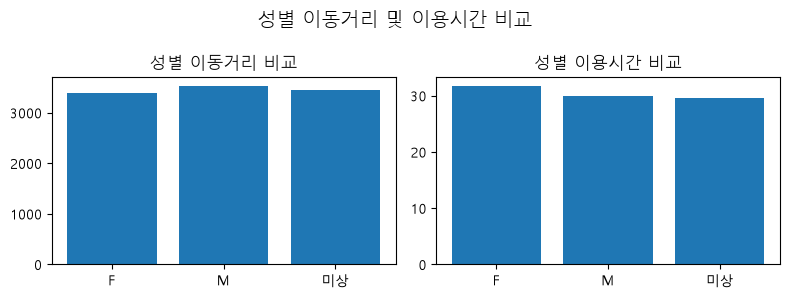

In [75]:
fig, axes = plt.subplots(1,2, figsize=(8,3))

axes[0].bar(gender_data['성별'],
            gender_data['이동거리(M)/건별'])
axes[0].set_title('성별 이동거리 비교')


axes[1].bar(gender_data['성별'],
            gender_data['이용시간(분)/건별'])
axes[1].set_title('성별 이용시간 비교')

plt.suptitle("성별 이동거리 및 이용시간 비교", fontsize=14)
plt.tight_layout()
plt.show()

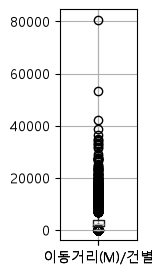

In [86]:
# 이상치 데이터 확인 - 건별 이동거리 / 건별 이용시간
plt.figure(figsize=(1,3))
df.boxplot(column="이용시간(분)/건별")
df.boxplot(column="이동거리(M)/건별")

plt.show()

In [ ]:
df.head()

In [87]:
df[df['대여소번호']==120].count()

대여일자          1
대여소번호         1
대여소명          1
대여구분코드        1
성별            1
연령대코드         1
이용건수          1
운동량           1
탄소량           1
이동거리(M)       1
이용시간(분)       1
월             1
운동량/건별        1
탄소량/건별        1
이동거리(M)/건별    1
이용시간(분)/건별    1
dtype: int64

In [88]:
df['이동거리(M)/건별'].max()

np.float64(80516.87)

In [92]:
df[df['이동거리(M)/건별']==80516.87]
df[df['이동거리(M)/건별'] > 30_000]
df[df['이동거리(M)/건별'] > 30_000].sort_values(by='이동거리(M)/건별',ascending=False)

,대여일자,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분),월,운동량/건별,탄소량/건별,이동거리(M)/건별,이용시간(분)/건별
2104,2026-06-01,2094,2094.숭실대학교(중문),일일권(비회원 3시간),미상,기타,1,2072.50,18.68,80516.87,589,6,2072.50,18.68,80516.87,589.0
3919,2026-06-01,1858,"1858. 500번,507번 버스 종점 앞",일일권(3시간),M,20대,1,1375.75,12.40,53448.09,121,6,1375.75,12.40,53448.09,121.0
4257,2026-06-01,869,869.노들섬 동측 앞,일일권(3시간),M,~10대,1,1086.88,9.80,42225.38,178,6,1086.88,9.80,42225.38,178.0
2816,2026-06-01,1158,1158. 가양역 8번출구,일일권(3시간),미상,40대,2,1995.86,17.99,77539.29,345,6,997.93,8.99,38769.64,172.5
276,2026-06-01,1708,1708. 도봉보건소사거리,일일권(3시간),M,40대,4,3735.61,33.66,145128.57,772,6,933.90,8.41,36282.14,193.0
4973,2026-06-01,912,912. 응암오거리,일일권(3시간),M,~10대,2,1792.29,16.16,69630.38,262,6,896.14,8.08,34815.19,131.0
1728,2026-06-01,4618,4618. 풍전아파트 건너편,일일권(3시간),M,50대,1,888.79,8.01,34529.37,131,6,888.79,8.01,34529.37,131.0
2194,2026-06-01,4098,4098.창동역 1번출구 인근,일일권(3시간),미상,기타,1,880.57,7.94,34210.00,124,6,880.57,7.94,34210.00,124.0
4165,2026-06-01,4693,4693. 수색감리교회,일일권(3시간),F,30대,1,860.28,7.75,33421.93,152,6,860.28,7.75,33421.93,152.0
1794,2026-06-01,2091,2091. 이수역9번출구,일일권,F,50대,1,851.60,7.68,33084.52,167,6,851.60,7.68,33084.52,167.0


In [93]:
# 월별 추이 -> 데이터 추가

df_1_6=pd.read_csv("../data/서울특별시 공공자전거 이용정보(월별)_26.1-6.csv", encoding='cp949')
df_1_6

,대여일자,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분)
0,202601,102,102. 망원역 1번출구 앞,일일권,NaN,20대,7,313.42,2.76,11927.89,82
1,202601,102,102. 망원역 1번출구 앞,일일권,NaN,30대,15,680.77,6.57,28380.64,281
2,202601,102,102. 망원역 1번출구 앞,일일권,NaN,40대,5,281.56,2.60,11177.03,112
3,202601,102,102. 망원역 1번출구 앞,일일권,NaN,50대,1,46.27,0.36,1537.28,10
4,202601,102,102. 망원역 1번출구 앞,일일권,F,20대,40,2288.99,20.31,89410.71,806
...,...,...,...,...,...,...,...,...,...,...,...
655811,202606,6190,6190.마곡광장(마곡나루역 6번출구),정기권,M,50대,101,2924.79,25.97,112158.08,915
655812,202606,6190,6190.마곡광장(마곡나루역 6번출구),정기권,M,60대,26,955.09,8.57,37105.05,302
655813,202606,6190,6190.마곡광장(마곡나루역 6번출구),정기권,M,70대이상,10,314.59,2.84,12221.50,132
655814,202606,6190,6190.마곡광장(마곡나루역 6번출구),정기권,M,~10대,31,1244.79,11.12,48014.67,446


In [ ]:
df_1_6['대여일자'] = pd.to_datetime(df_1_6['대여일자'], format="%Y%m") #대문자
df_1_6['월'] = df_1_6['대여일자'].dt.month
df_1_6.head()


,대여일자,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분),월
0,2026-01-01,102,102. 망원역 1번출구 앞,일일권,NaN,20대,7,313.42,2.76,11927.89,82,1
1,2026-01-01,102,102. 망원역 1번출구 앞,일일권,NaN,30대,15,680.77,6.57,28380.64,281,1
2,2026-01-01,102,102. 망원역 1번출구 앞,일일권,NaN,40대,5,281.56,2.60,11177.03,112,1
3,2026-01-01,102,102. 망원역 1번출구 앞,일일권,NaN,50대,1,46.27,0.36,1537.28,10,1
4,2026-01-01,102,102. 망원역 1번출구 앞,일일권,F,20대,40,2288.99,20.31,89410.71,806,1


In [99]:
monthly = df_1_6.groupby("월")['이용건수'].sum().reset_index()
monthly

,월,이용건수
0,1,1595817
1,2,1744693
2,3,2842284
3,4,3824308
4,5,3905121
5,6,4066671


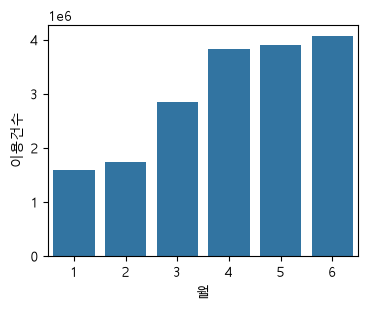

In [100]:
plt.figure(figsize=(4,3))
sns.barplot(data=monthly,
            x='월',
            y='이용건수')
plt.show()

# plt.bar(monthly)

In [ ]:
# 계절성 --> concat
# 사용시 거리를 계절별, 대여권 종류별(정기권, 일일권)
# 연령대


In [113]:
df_1_6['대여구분코드'].unique()
df_1_6['대여구분코드'].value_counts(normalize=True).round(3).mul(100)

대여구분코드
정기권             48.9
일일권             37.7
일일권(3시간)         5.3
일일권(비회원)         4.8
가족권              1.8
가족권(2시간)         0.7
일일권(비회원 3시간)     0.6
가족권(3시간)         0.1
Name: proportion, dtype: float64

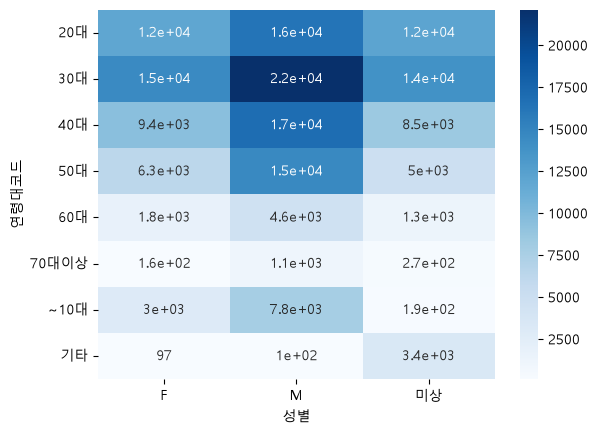

In [ ]:
pivot = df.pivot_table(index='연령대코드',
                       columns="성별",
                       values="이용건수",
                       aggfunc="sum")

sns.heatmap(pivot,
            annot=True,
            cmap="Blues")
plt.show()